In [23]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [24]:
import geoflowkit as gfk
from geoflowkit import FTSNE

In [25]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'

In [26]:
def constrained_layout(ax, x, y, eps=0.03):
    min_x, max_x = min(x), max(x)
    x_eps = eps * (max_x - min_x)
    min_y, max_y = min(y), max(y)
    y_eps = eps * (max_y - min_y)
    ax.set_xlim(min_x - x_eps, max_x + x_eps)
    ax.set_ylim(min_y - y_eps, max_y + y_eps)

In [ ]:
def get_color_map(flow_types):
    colors = [
        'black',      # 黑色
        'red',        # 红色
        'blue',       # 蓝色
        'green',      # 绿色
        'gold',       # 金色
        'magenta',    # 洋红色
        'cyan',       # 青色
        'purple',     # 紫色
        'brown',      # 棕色
        'pink',       # 粉色
    ]
    color_map = {'random': 'gray'}
    num = 0
    for flow_type in flow_types:
        if flow_type=='random':
            continue
        if num>=len(colors):
            color_map[flow_type] = 'white'
        else:
            color_map[flow_type] = colors[num]
        num += 1
    return color_map

def map_flow_color(flow_types):
    if isinstance(flow_types, pd.Series):
        unique_flow_types = flow_types.unique()
    elif isinstance(flow_types, np.ndarray):
        unique_flow_types = np.unique(flow_types)
    else:
        flow_types = np.array(flow_types)
        unique_flow_types = np.unique(flow_types)
    unique_flow_types = np.sort(unique_flow_types)
    color_map = get_color_map(unique_flow_types)
    colors = [color_map[flow_type] for flow_type in flow_types]

    return colors

# Simulated dataset 1 visualisation

In [28]:
path = './data/sys_flow/sys_flow_dataset1.gpkg'
layers = ['RP', 'CP', 'CvP', 'DvP']
fdfs = []
for i, layer in enumerate(layers):
    if i==0:
        fdf = gfk.read_file(path, layer=layer)
    elif i==1:
        fdf = gfk.read_file(path, layer=layer)
    else:
        fdf = gfk.read_file(path, layer=layer)
    fdfs.append(fdf)
    print(fdf.shape)

(1000, 8)
(150, 8)
(180, 8)
(200, 8)


## Global interpretability

In [29]:
X_embeddeds1 = []
perplexitys = [200, 100, 100, 80]
for i, gfd in enumerate(fdfs[:4]):
    transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                        perplexity=perplexitys[i], log_progress='notebook', 
                        early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
    X_embedded = transformer.fit_transform(fdfs[i], identity={'o': 0, 'd': 1})
    X_embeddeds1.append(X_embedded)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

## Local interpretability

In [30]:
X_embeddeds2 = []
perplexitys = [200, 60, 100, 100]
for i, gfd in enumerate(fdfs[:4]):
    transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                        perplexity=perplexitys[i], log_progress='notebook', 
                        early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
    X_embedded = transformer.fit_transform(fdfs[i], union={('o', 'd'): (0, 1)})
    X_embeddeds2.append(X_embedded)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

## Plotting

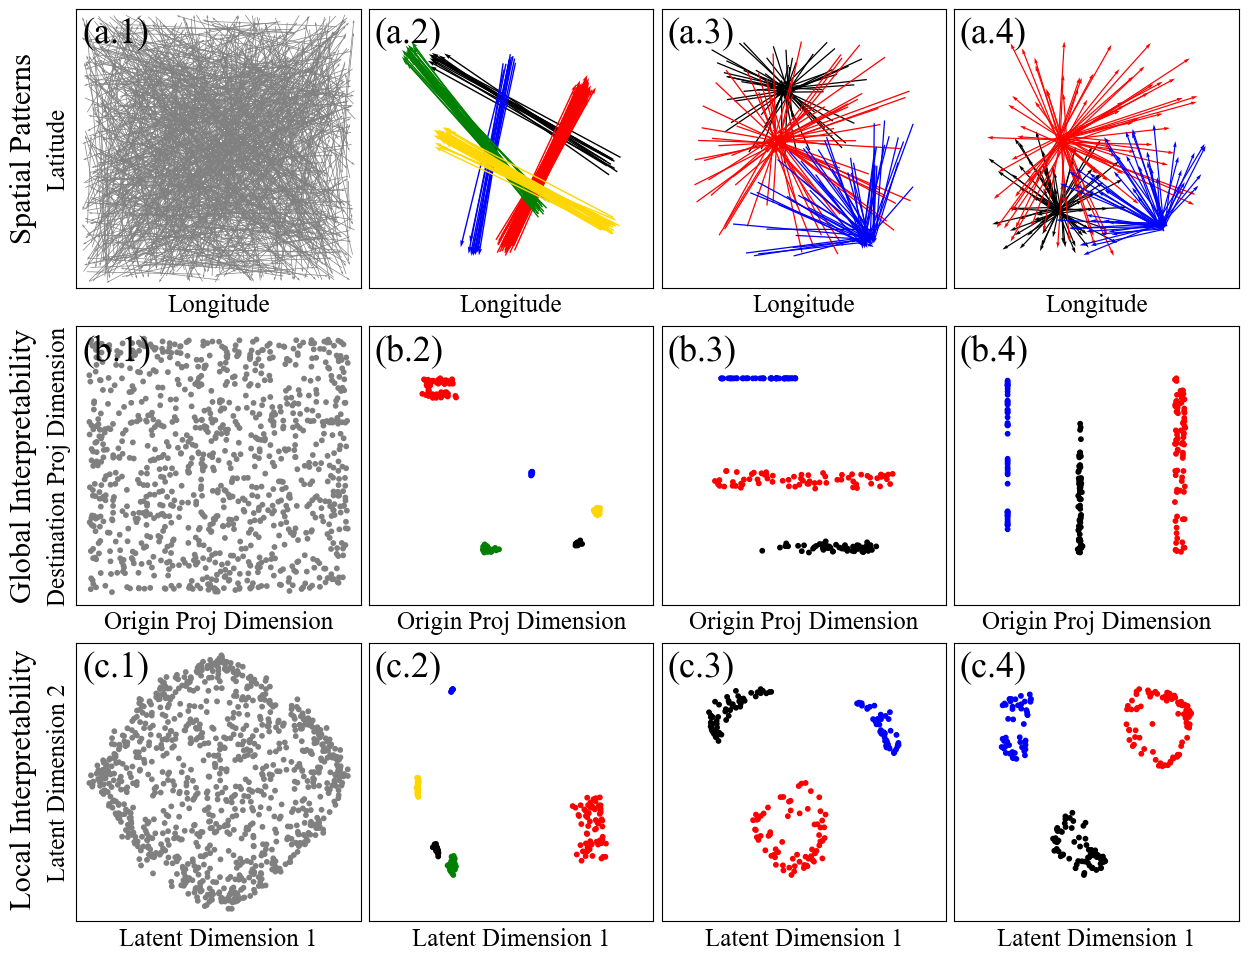

In [31]:
# 创建一个整体为 3x4 网格的画布
fig = plt.figure(figsize=(12, 9.5), constrained_layout=True)

# 使用 GridSpec 创建一个 3x4 的网格
gs = gridspec.GridSpec(3, 4, figure=fig)

label_fontsize, text_fontsize = 18, 26
for i, fdf in enumerate(fdfs[:4]):
    ax = fig.add_subplot(gs[0, i])
    flow_colors = map_flow_color(fdfs[i]['flow_type'])
    if i>0:
        fdf.plot(ax=ax, color=flow_colors, zoom=0.15)
    else:
        fdf.plot(ax=ax, color=flow_colors, zoom=0.02)
    ax.axes.xaxis.set_ticks([])
    ax.axes.yaxis.set_ticks([])
    ax.set_xlabel('Longitude', fontsize=label_fontsize)
    if i==0:
        ax.set_ylabel('Latitude', fontsize=label_fontsize)
    ax.text(0.02, 0.88, f'(a.{i+1})', fontsize=text_fontsize, transform=ax.transAxes)

for i, fdf in enumerate(fdfs[:4]):
    ax = fig.add_subplot(gs[1, i])
    flow_colors = map_flow_color(fdfs[i]['flow_type'])
    ax.scatter(X_embeddeds1[i][:, 0], X_embeddeds1[i][:, 1], c=flow_colors, s=10)
    ax.axes.xaxis.set_ticks([])
    ax.axes.yaxis.set_ticks([])
    ax.set_xlabel('Origin Proj Dimension', fontsize=label_fontsize)
    if i == 0:
        ax.set_ylabel('Destination Proj Dimension', fontsize=label_fontsize)
    ax.text(0.02, 0.88, f'(b.{i+1})', fontsize=text_fontsize, transform=ax.transAxes)
    if i>0:
        constrained_layout(ax, X_embeddeds1[i][:, 0], X_embeddeds1[i][:, 1], eps=0.3)
    else:
        constrained_layout(ax, X_embeddeds1[i][:, 0], X_embeddeds1[i][:, 1], eps=0.05)

for i, fdf in enumerate(fdfs[:4]):
    ax = fig.add_subplot(gs[2, i])
    flow_colors = map_flow_color(fdfs[i]['flow_type'])
    ax.scatter(X_embeddeds2[i][:, 0], X_embeddeds2[i][:, 1], c=flow_colors, s=10)
    ax.axes.xaxis.set_ticks([])
    ax.axes.yaxis.set_ticks([])
    ax.set_xlabel('Latent Dimension 1', fontsize=label_fontsize)
    if i==0:
        ax.set_ylabel('Latent Dimension 2', fontsize=label_fontsize)
    ax.text(0.02, 0.88, f'(c.{i+1})', fontsize=text_fontsize, transform=ax.transAxes)
    if i>0:
        constrained_layout(ax, X_embeddeds2[i][:, 0], X_embeddeds2[i][:, 1], eps=0.25)
    else:
        constrained_layout(ax, X_embeddeds2[i][:, 0], X_embeddeds2[i][:, 1], eps=0.05)

size = 22
fig.text(-0.016, 0.85, 'Spatial Patterns', ha='center', va='center', rotation='vertical', fontsize=size)
fig.text(-0.016, 0.516, 'Global Interpretability', ha='center', va='center', rotation='vertical', fontsize=size)
fig.text(-0.016, 0.185, 'Local Interpretability', ha='center', va='center', rotation='vertical', fontsize=size)
plt.show()

# Simulated dataset 2 visualisation

In [32]:
fdf = gfk.read_file('./data/sys_flow/sys_flow_dataset2.gpkg')
flow_colors = map_flow_color(fdf['flow_type'])

In [33]:
transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                    perplexity=300, log_progress='notebook', 
                    early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
X_embedded = transformer.fit_transform(fdf, identity={'o': 0, 'd': 1})

  0%|          | 0/100 [00:00<?, ?it/s]

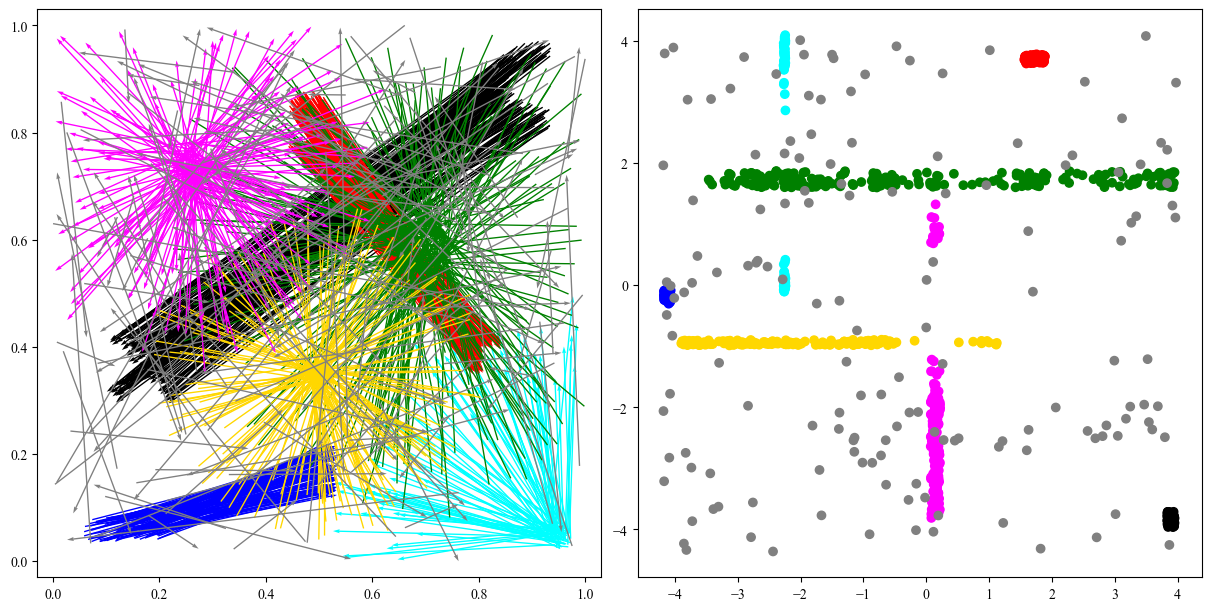

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
fdf.plot(ax=ax1, color=flow_colors)
ax2.scatter(X_embedded[:, 0], X_embedded[:, 1], c=flow_colors);

In [35]:
transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                    perplexity=200, log_progress='notebook', 
                    early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
X_embedded = transformer.fit_transform(fdf, union={('o', 'd'): (0, 1)}, relation='distance')

  0%|          | 0/100 [00:00<?, ?it/s]

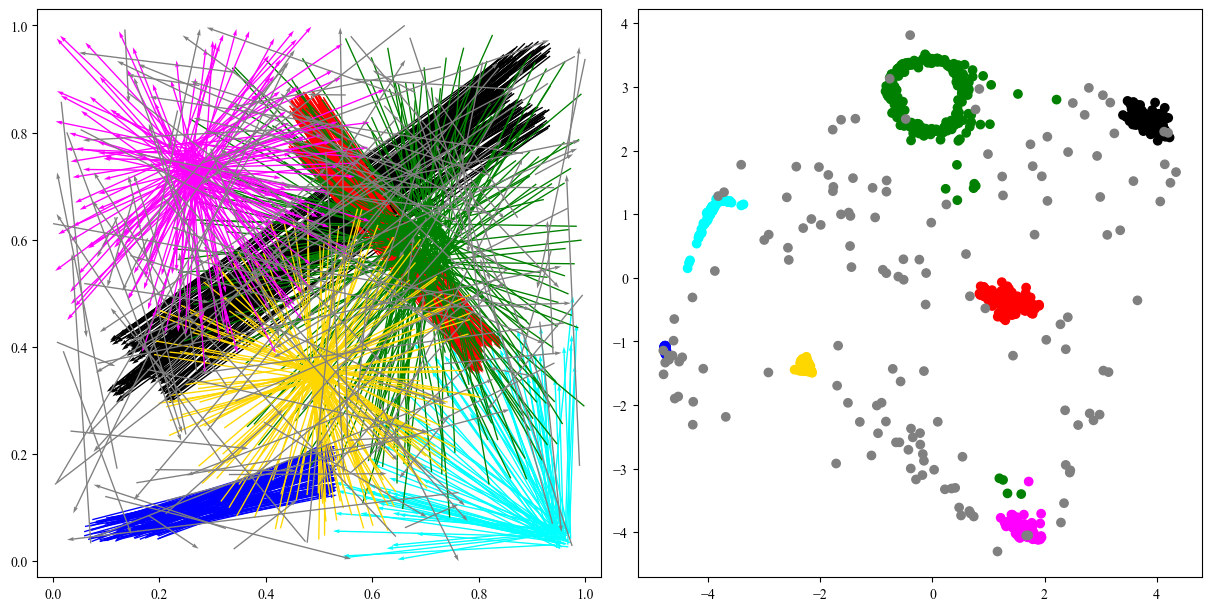

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
fdf.plot(ax=ax1, color=flow_colors)
ax2.scatter(X_embedded[:, 0], X_embedded[:, 1], c=flow_colors);

# Simulated dataset 3 visualisation

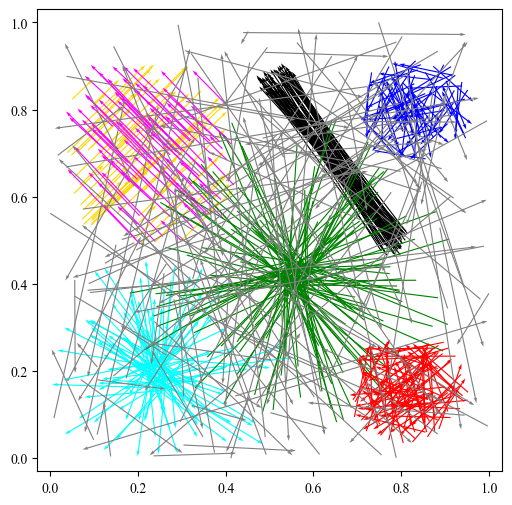

In [37]:
fdf = gfk.read_file('./data/sys_flow/sys_flow_dataset3.gpkg')
flow_colors = np.array(map_flow_color(fdf['flow_type']))
fdf.plot(figsize=(6, 6), color=flow_colors);

In [38]:
transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                    perplexity=200, log_progress='notebook', 
                    early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
X_embedded = transformer.fit_transform(fdf, identity={'length': 1, 'angle': 2}, union={('o', 'd'): 0})

  0%|          | 0/100 [00:00<?, ?it/s]

In [39]:
oxs, oys = fdf[['ox', 'oy']].values[:, :2].T
delta_xs = fdf['dx'].values - fdf['ox'].values
delta_ys = fdf['dy'].values - fdf['oy'].values

In [40]:
type_label = {'random': 'RP cluster', 'cluster1': 'CP cluster', 'gather1': 'CvP cluster', 'scatter1': 'DvP cluster', 
    'parallel1': 'PP cluster1', 'parallel2': 'PP cluster2', 'equilong1': 'EP cluster1', 'equilong2': 'EP cluster2'}

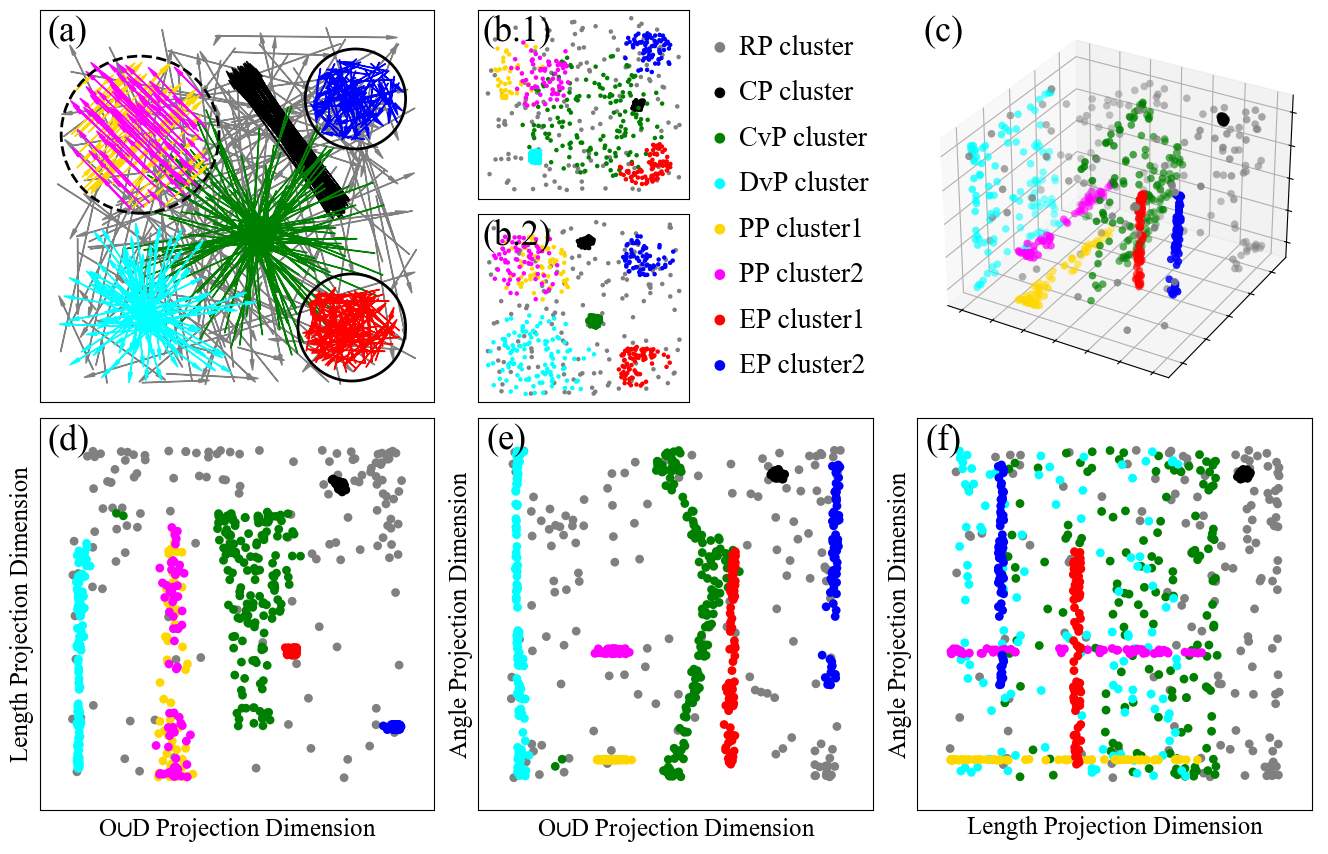

In [41]:
# 创建一个整体为 2x2 网格的画布
fig = plt.figure(figsize=(13, 10.4))

# 使用 GridSpec 创建一个 4x6 的网格
gs = gridspec.GridSpec(4, 6, figure=fig, width_ratios=[1, 1, 1.2, 0.8, 1, 1])

label_fontsize = 18
text_fontsize = 26
ax_flow = fig.add_subplot(gs[:2, :2])
ax_flow.text(0.02, 0.92, f'(a)', fontsize=text_fontsize, transform=ax_flow.transAxes)
ax_small1 = fig.add_subplot(gs[:1, 2])
ax_small1.text(0.02, 0.84, f'(b.1)', fontsize=text_fontsize, transform=ax_small1.transAxes)
ax_small2 = fig.add_subplot(gs[1:2, 2])
ax_small2.text(0.02, 0.84, f'(b.2)', fontsize=text_fontsize, transform=ax_small2.transAxes)

ax_emb1 = fig.add_subplot(gs[2:, :2])
ax_emb1.text(0.02, 0.92, f'(d)', fontsize=text_fontsize, transform=ax_emb1.transAxes)
ax_emb1.set_xlabel(r'O' +r'$\cup$' 'D Projection Dimension', fontsize=label_fontsize)
ax_emb1.set_ylabel('Length Projection Dimension', fontsize=label_fontsize)
ax_emb2 = fig.add_subplot(gs[2:, 2:4])
ax_emb2.text(0.02, 0.92, f'(e)', fontsize=text_fontsize, transform=ax_emb2.transAxes)
ax_emb2.set_xlabel(r'O' +r'$\cup$' 'D Projection Dimension', fontsize=label_fontsize)
ax_emb2.set_ylabel('Angle Projection Dimension', fontsize=label_fontsize)
ax_emb3 = fig.add_subplot(gs[2:, 4:6])
ax_emb3.text(0.02, 0.92, f'(f)', fontsize=text_fontsize, transform=ax_emb3.transAxes)
ax_emb3.set_xlabel('Length Projection Dimension', fontsize=label_fontsize)
ax_emb3.set_ylabel('Angle Projection Dimension', fontsize=label_fontsize)

handles = []
for fp in type_label.keys():
    mask = fdf['flow_type'].values == fp
    label = type_label[fp]
    for ox, oy, delta_x, delta_y, color in zip(oxs[mask], oys[mask], delta_xs[mask], delta_ys[mask], flow_colors[mask]):
        ax_flow.arrow(ox, oy, delta_x, delta_y, head_width=0.01, head_length=0.03, 
                      fc=color, ec=color, length_includes_head=True, alpha=1)
    ax_small1.scatter(fdf['ox'].values[mask], fdf['oy'].values[mask], c=flow_colors[mask], s=5)
    scatter = ax_small2.scatter(fdf['dx'].values[mask], fdf['dy'].values[mask], c=flow_colors[mask], s=5, label=label)
    ax_emb1.scatter(X_embedded[mask, 0], X_embedded[mask, 1], c=flow_colors[mask], s=40, edgecolors='none')
    ax_emb2.scatter(X_embedded[mask, 0], X_embedded[mask, 2], c=flow_colors[mask], s=40, edgecolors='none')
    ax_emb3.scatter(X_embedded[mask, 1], X_embedded[mask, 2], c=flow_colors[mask], s=40, edgecolors='none')
    handles.append(scatter)
constrained_layout(ax_emb1, X_embedded[:, 0], X_embedded[:, 1], 0.1)
constrained_layout(ax_emb2, X_embedded[:, 0], X_embedded[:, 2], 0.1)
constrained_layout(ax_emb3, X_embedded[:, 1], X_embedded[:, 2], 0.1)
circle =plt.Circle((0.23, 0.7), 0.22, edgecolor='black', linestyle='--', fill=False, linewidth=2)
ax_flow.add_patch(circle)
circle =plt.Circle((0.82, 0.16), 0.15, edgecolor='black', linestyle='-', fill=False, linewidth=2)
ax_flow.add_patch(circle)
circle =plt.Circle((0.83, 0.8), 0.14, edgecolor='black', linestyle='-', fill=False, linewidth=2)
ax_flow.add_patch(circle)

ax_emb3d = fig.add_subplot(gs[:2, 4:], projection='3d')
fig.text(0.68, 0.85, '(c)', fontsize=text_fontsize)
ax_emb3d.scatter(X_embedded[:, 0], X_embedded[:, 1], X_embedded[:, 2], c=flow_colors, s=30, edgecolors='none')
ax_emb3d.axes.xaxis.set_ticklabels([])
ax_emb3d.axes.yaxis.set_ticklabels([])
ax_emb3d.axes.zaxis.set_ticklabels([])

for ax in [ax_flow, ax_small1, ax_small2, ax_emb1, ax_emb2, ax_emb3]:
    ax.axes.xaxis.set_ticks([])
    ax.axes.yaxis.set_ticks([])

# 添加图例
fig.legend(handles=handles, ncols=1, loc='upper center', bbox_to_anchor=(0.57, 0.88), frameon=False, markerscale=3,
           borderaxespad=0.5, labelspacing=0.7, handletextpad=-0.3, columnspacing=1.8, fontsize=20)
plt.subplots_adjust(hspace=0.08, wspace=0.25, left=0.0001, right=0.979)
plt.show()

# Shenzhen Taxi Flow dataset visualization

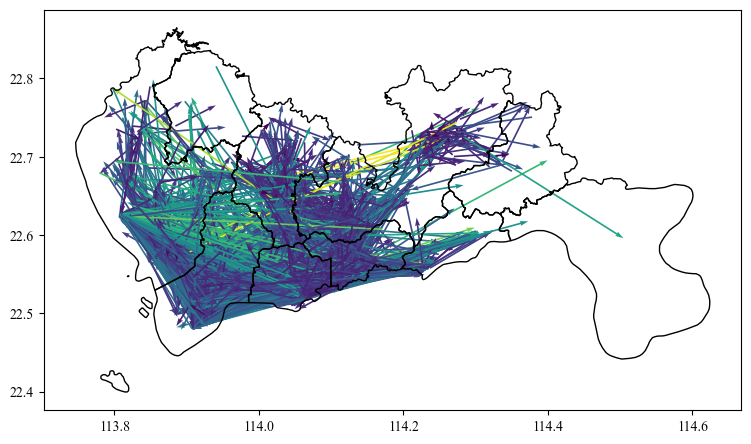

In [62]:
fdf = gfk.read_csv('./data/sz_data/sz_taxi_flow.csv', use_cols=['ox', 'oy', 'dx', 'dy'], crs='EPSG:4326')
mask1 = fdf['time_difference'].values > 60*30
mask2 = fdf['distance'].values > 5
fdf = fdf.loc[mask1 | mask2]
gdf = gpd.read_file('./data/sz_data/sz_border.gpkg')
ax = fdf.plot(figsize=(9, 6), column='distance')
gdf.plot(ax=ax, facecolor="none", edgecolor="black");

## Comparision of exact and barnes_hut method

In [43]:
transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                    perplexity=300, log_progress='notebook', method='exact', 
                    early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
# totally used 1m21.4s, 100 iterations used 1m6s, 1.55it/s
X_embedded_exact = transformer.fit_transform(fdf.to_crs(4526), identity={'o': 0, 'd': 1})

  0%|          | 0/100 [00:00<?, ?it/s]

In [70]:
transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                    perplexity=300, log_progress='notebook', method='barnes_hut', 
                    early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
# totally used 21.7s, 100 iterations used 17s, 5.95it/s
X_embedded_bh = transformer.fit_transform(fdf.to_crs(4526), identity={'o': 0, 'd': 1})

  0%|          | 0/100 [00:00<?, ?it/s]

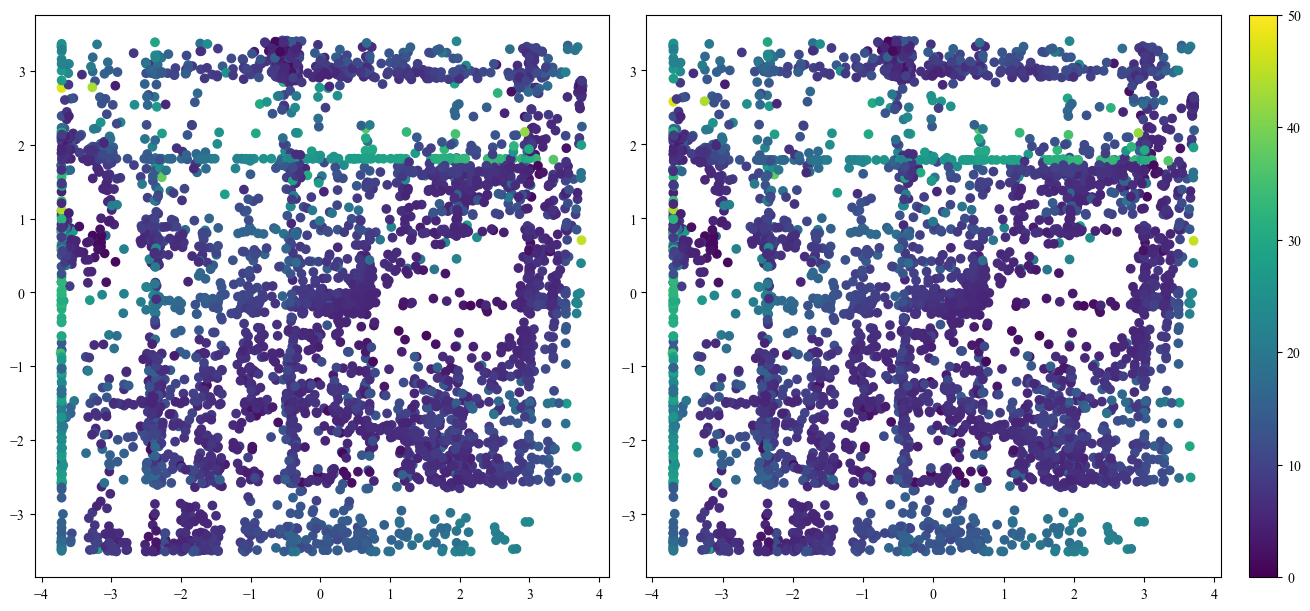

In [72]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)

scatter = ax1.scatter(X_embedded_exact[:, 0], X_embedded_exact[:, 1], c=fdf['distance'].values, vmin=0, vmax=50)
scatter = ax2.scatter(X_embedded_bh[:, 0], X_embedded_bh[:, 1], c=fdf['distance'].values, vmin=0, vmax=50)
fig.colorbar(scatter, ax=ax2);

## Comparision of local and global interpretability vis result

In [73]:
transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                    perplexity=300, log_progress='notebook', method='barnes_hut', 
                    early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
X_embedded_local = transformer.fit_transform(fdf.to_crs(4526), identity={'o': 0, 'd': 1})

  0%|          | 0/100 [00:00<?, ?it/s]

In [82]:
transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                    perplexity=100, log_progress='notebook', method='exact', 
                    early_exaggeration=12.0, early_exaggeration_iter=10, verbose=1)
X_embedded_global = transformer.fit_transform(fdf.to_crs(4526), union={('o', 'd'): (0, 1)})

  0%|          | 0/100 [00:00<?, ?it/s]

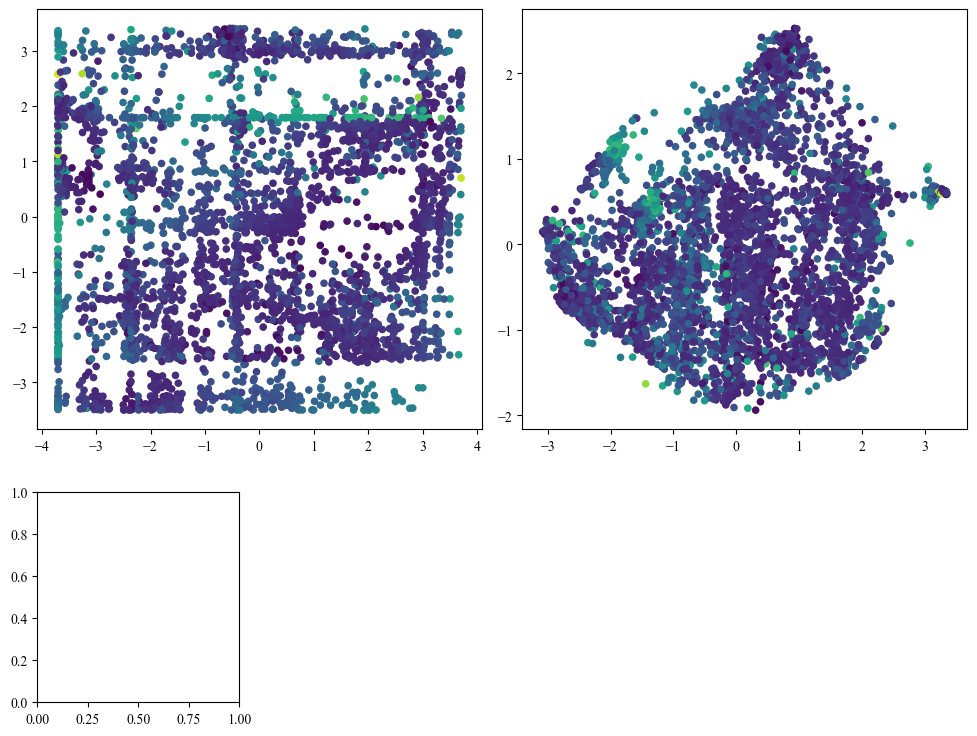

In [83]:
# 创建一个整体为 2x2 网格的画布
fig = plt.figure(figsize=(12, 9))

# 使用 GridSpec 创建一个 2x4 的网格
gs = gridspec.GridSpec(2, 4, figure=fig, height_ratios=[6, 3], width_ratios=[1, 1, 1, 1])

ax_local = fig.add_subplot(gs[:1, :2])
ax_global = fig.add_subplot(gs[:1, 2:])

scatter_exact = ax_local.scatter(X_embedded_local[:, 0], X_embedded_local[:, 1],
                                 c=fdf['distance'].values, vmin=0, vmax=50, s=20)
scatter_bh = ax_global.scatter(X_embedded_global[:, 0], X_embedded_global[:, 1], 
                               c=fdf['distance'].values, vmin=0, vmax=50, s=20)

ax_local_ex1 = fig.add_subplot(gs[1, 0])

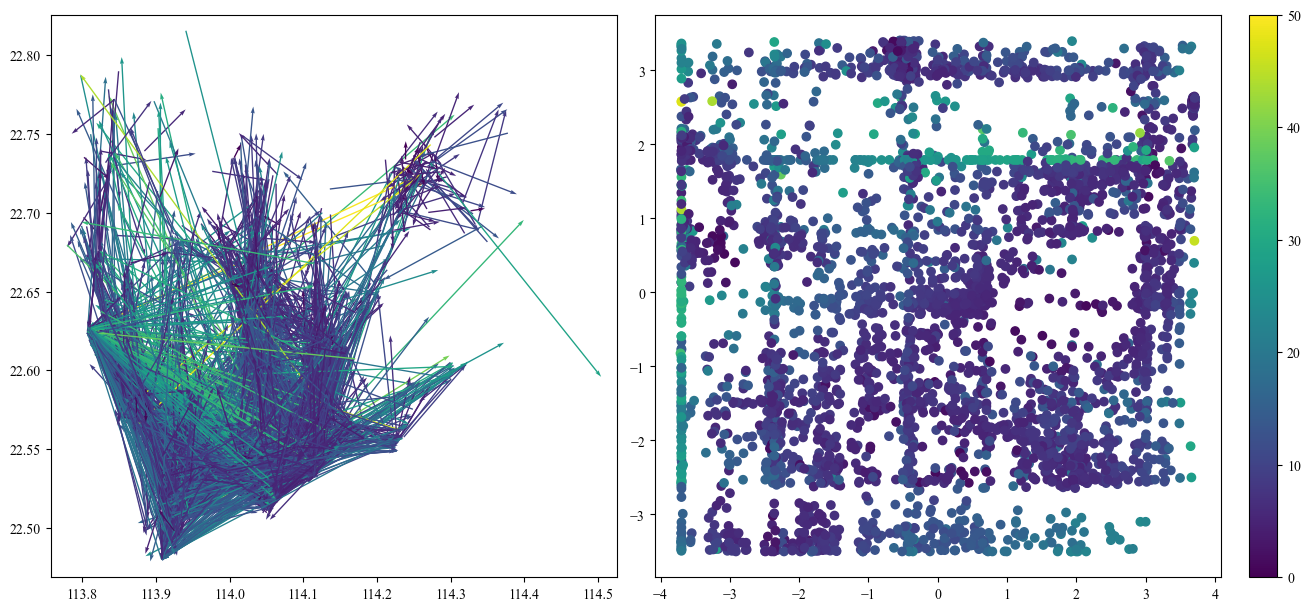

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
fdf.plot(ax=ax1, column='distance')
scatter = ax2.scatter(X_embedded[:, 0], X_embedded[:, 1], c=fdf['distance'].values, vmin=0, vmax=50)
fig.colorbar(scatter, ax=ax2);

In [23]:
transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                    perplexity=300, log_progress='notebook', method='exact', 
                    early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
# totally used 1m21.4s, 100 iterations used 1m6s, 1.55it/s
X_embedded = transformer.fit_transform(fdf.to_crs(4526), identity={'o': 0, 'd': 1})

  0%|          | 0/100 [00:00<?, ?it/s]

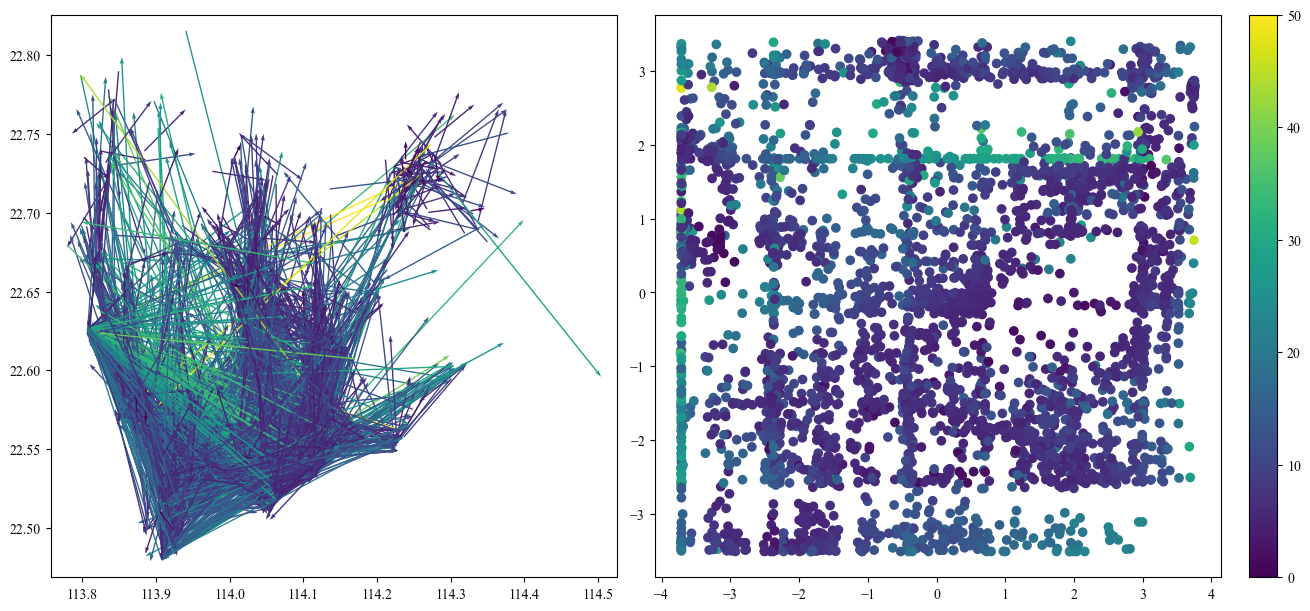

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
fdf.plot(ax=ax1, column='distance')
scatter = ax2.scatter(X_embedded[:, 0], X_embedded[:, 1], c=fdf['distance'].values, vmin=0, vmax=50)
fig.colorbar(scatter, ax=ax2);